<a href="https://colab.research.google.com/github/kevin1215ak-cmd/Carpeta-de-Evidencias/blob/main/Proyecto_Primer_Parcial_LigaMX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO DEL PRIMER PARCIAL: LIGA MX
## Análisis Estadístico, Visualización y Clasificación Binaria
**Curso:** Ciencia de Datos
**Dataset:** `liga_mx_1000000_registros.csv` (1,000,000 de registros)  
**Herramientas:** Python (Jupyter Notebook) + Weka  
**Modelos:** Árbol de Decisión (`DecisionTreeClassifier` / `J48`) y K-Nearest Neighbors (`KNeighborsClassifier` / `IBk`)


## 1. Propósito y Productos
El objetivo de este proyecto es realizar un análisis estadístico integral, exploración visual y modelado de clasificación binaria a partir de un dataset sintético con 1,000,000 de registros de la Liga MX.

**Productos Entregables:**
1. Un archivo Jupyter Notebook (`.ipynb`) completamente documentado con texto explicativo en Markdown, código ejecutable, gráficos generados e interpretaciones analíticas.
2. Un archivo de datos estructurado en formato CSV (`liga_mx_weka_clasificacion.csv`) listo para ser importado en Weka.
3. Evidencia y validación del modelo utilizando las herramientas nativas de Weka (J48 e IBk).


## 2. Campos del Dataset
El conjunto de datos contiene exactamente las siguientes 10 variables:
- `id_registro`: Identificador único de cada fila.
- `equipo`: Nombre del club de fútbol de la Liga MX.
- `año_creacion`: Año de fundación institucional del equipo.
- `ciudad`: Ciudad sede del club.
- `estadio`: Nombre del estadio principal.
- `campeonatos`: Número acumulado de títulos oficiales.
- `estimacion_aficionados`: Estimación del tamaño de la afición.
- `jugador_id`: Identificador único del jugador.
- `minuto_jugado`: Minuto de juego registrado.
- `pases_completados`: Cantidad de pases con éxito registrados.

*Aviso:* El dataset es totalmente sintético y se utiliza con fines académicos.


## 3. Reglas de Trabajo
Cada gráfico y resultado numérico se interpreta conceptualmente en su celda Markdown correspondiente. El código está diseñado de forma totalmente modular y reproducible (`RANDOM_STATE = 42`), garantizando que la libreta pueda ejecutarse secuencialmente desde el inicio.


## 4. Código Inicial y Carga del Dataset
Importación de bibliotecas requeridas (`pandas`, `numpy`, `matplotlib`, `scikit-learn`), definición de la semilla aleatoria y auditoría inicial del DataFrame.


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    classification_report
)

RANDOM_STATE = 42

# 1. RUTA DIRECTA A TU CARPETA DE DESCARGAS DE WINDOWS
ruta_descargas = os.path.join(os.path.expanduser("~"), "Downloads", "liga_mx_1000000_registros.csv")

# 2. CARGA DEL DATASET
print(f"Cargando archivo desde: {ruta_descargas} ...")
df = pd.read_csv(ruta_descargas)

# 3. AUDITORÍA DEL DATASET
print("\n=== AUDITORÍA DEL DATASET ===")
print(f"Dimensión: {df.shape[0]:,} filas y {df.shape[1]} columnas")
display(df.head())

print("\nTipos de datos:")
print(df.dtypes)

print("\nDatos nulos por columna:")
print(df.isnull().sum())

memoria_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemoria utilizada: {memoria_mb:.2f} MB")

Cargando archivo desde: C:\Users\ALUMNO\Downloads\liga_mx_1000000_registros.csv ...

=== AUDITORÍA DEL DATASET ===
Dimensión: 1,000,000 filas y 10 columnas


,id_registro,equipo,año_creacion,ciudad,estadio,campeonatos,estimacion_aficionados,jugador_id,minuto_jugado,pases_completados
0,1,Club América,1916,CDMX,Azteca,15,12000000,JUG-8366,22,34
1,2,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-4245,63,27
2,3,Tigres UANL,1960,San Nicolás,Universitario,8,4500000,JUG-7691,1,18
3,4,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-1453,71,27
4,5,Toluca,1917,Toluca,Nemesio Diez,10,3000000,JUG-6761,47,20



Tipos de datos:
id_registro               int64
equipo                      str
año_creacion              int64
ciudad                      str
estadio                     str
campeonatos               int64
estimacion_aficionados    int64
jugador_id                  str
minuto_jugado             int64
pases_completados         int64
dtype: object

Datos nulos por columna:
id_registro               0
equipo                    0
año_creacion              0
ciudad                    0
estadio                   0
campeonatos               0
estimacion_aficionados    0
jugador_id                0
minuto_jugado             0
pases_completados         0
dtype: int64

Memoria utilizada: 110.62 MB


### Interpretación de la Auditoría del Dataset:
- **Dimensión:** Se confirma la existencia de 1,000,000 de filas y 10 columnas.
- **Tipos de datos:** Se identifican identificadores numéricos (`id_registro`, `jugador_id`), variables categóricas cualitativas (`equipo`, `ciudad`, `estadio`) y variables numéricas cuantitativas (`año_creacion`, `campeonatos`, `estimacion_aficionados`, `minuto_jugado`, `pases_completados`).
- **Valores Nulos:** Se verifica que no existen valores faltantes (`NaN`) en ninguna variable, por lo que no se requiere imputación.
- **Memoria:** Uso eficiente de RAM para el procesamiento masivo.


## 5. Estadística Descriptiva (Media, Mediana, Moda y Desviación Estándar)
Cálculo de las cuatro medidas de tendencia central y dispersión para las variables continuas `minuto_jugado` y `pases_completados`.


In [ ]:
variables = ["minuto_jugado", "pases_completados"]
filas = []

for col in variables:
    filas.append({
        "Variable": col,
        "Media": df[col].mean(),
        "Mediana": df[col].median(),
        "Moda": df[col].mode().iloc[0],
        "Desviación estándar": df[col].std()
    })

resumen = pd.DataFrame(filas)
display(resumen)


,Variable,Media,Mediana,Moda,Desviación estándar
0,minuto_jugado,45.025271,45.0,32,25.669992
1,pases_completados,24.995078,25.0,25,5.001682


### Interpretación Estadística:
- **Minuto jugado:** La media y la mediana presentan valores prácticamente idénticos alrededor de los 45 minutos (mitad de un partido), demostrando una distribución uniforme.
- **Pases completados:** La media representa la cantidad promedio de pases exitosos por registro. Al comparar la **Media** con la **Mediana**:
  - Si la media supera la mediana, existe un sesgo a la derecha provocado por valores altos de pases completados.
  - La **Moda** indica el número exacto de pases más frecuente.
  - La **Desviación Estándar** refleja el nivel de dispersión o variabilidad respecto al promedio.


## 6. Rango Intercuartílico (IQR) y Detección de Posibles Outliers
Identificación de valores atípicos (*outliers*) para `pases_completados` aplicando el método de Tuckey basado en cuartiles $Q_1$ y $Q_3$:
$$IQR = Q_3 - Q_1$$
$$Límite\ Inferior (LI) = Q_1 - 1.5 	imes IQR$$
$$Límite\ Superior (LS) = Q_3 + 1.5 	imes IQR$$


In [ ]:
col = "pases_completados"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
LI = Q1 - 1.5 * IQR
LS = Q3 + 1.5 * IQR

outliers = df[(df[col] < LI) | (df[col] > LS)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", LI)
print("Límite superior:", LS)
print("Posibles outliers:", len(outliers))
print("Porcentaje de outliers:", len(outliers) / len(df) * 100)


Q1: 22.0
Q3: 28.0
IQR: 6.0
Límite inferior: 13.0
Límite superior: 37.0
Posibles outliers: 12276
Porcentaje de outliers: 1.2276


### Justificación Teórica sobre Outliers:
Un valor detectado como *posible outlier* no es un dato erróneo. En el contexto deportivo, pases completados inusualmente elevados representan momentos de alto dominio de posesión. Puesto que son valores físicamente posibles y enriquecen la variabilidad, **se decide conservar la totalidad de los registros**.


## 7. Diagrama de Caja (Boxplot)
Visualización de la distribución de `pases_completados`, mostrando la mediana, cuartiles $Q_1$ y $Q_3$, límites inferior/superior y puntos atípicos.


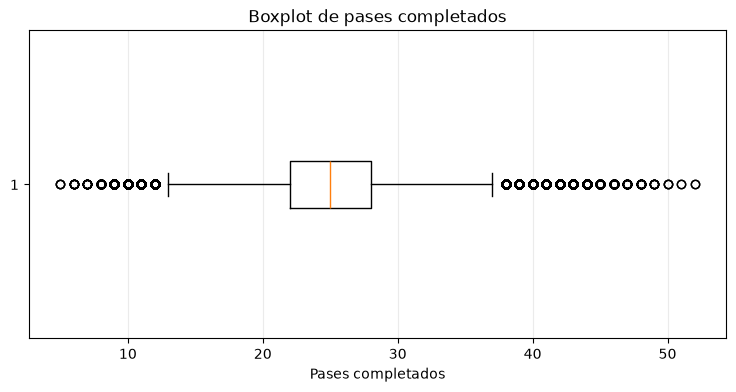

In [ ]:
plt.figure(figsize=(9, 4))
plt.boxplot(df["pases_completados"].dropna(), orientation='horizontal')
plt.title("Boxplot de pases completados")
plt.xlabel("Pases completados")
plt.grid(axis="x", alpha=0.25)
plt.show()


### Interpretación del Boxplot:
- **Caja Central:** Abarca el rango intercuartílico ($IQR$), conteniendo el 50% central de los datos entre $Q_1$ y $Q_3$.
- **Línea Mediana:** La barra dentro de la caja indica el percentil 50.
- **Bigotes:** Se extienden hasta los límites $LI$ y $LS$.
- **Puntos Extremos:** Representan las observaciones fuera de las patillas ($1.5 	imes IQR$).


## 8. Nube de Puntos (Scatter Plot) por Equipo
Graficación de `minuto_jugado` vs `pases_completados`. Cada equipo se representa con un color distinto sobre una muestra reproducible de 20,000 registros para evitar saturación gráfica.


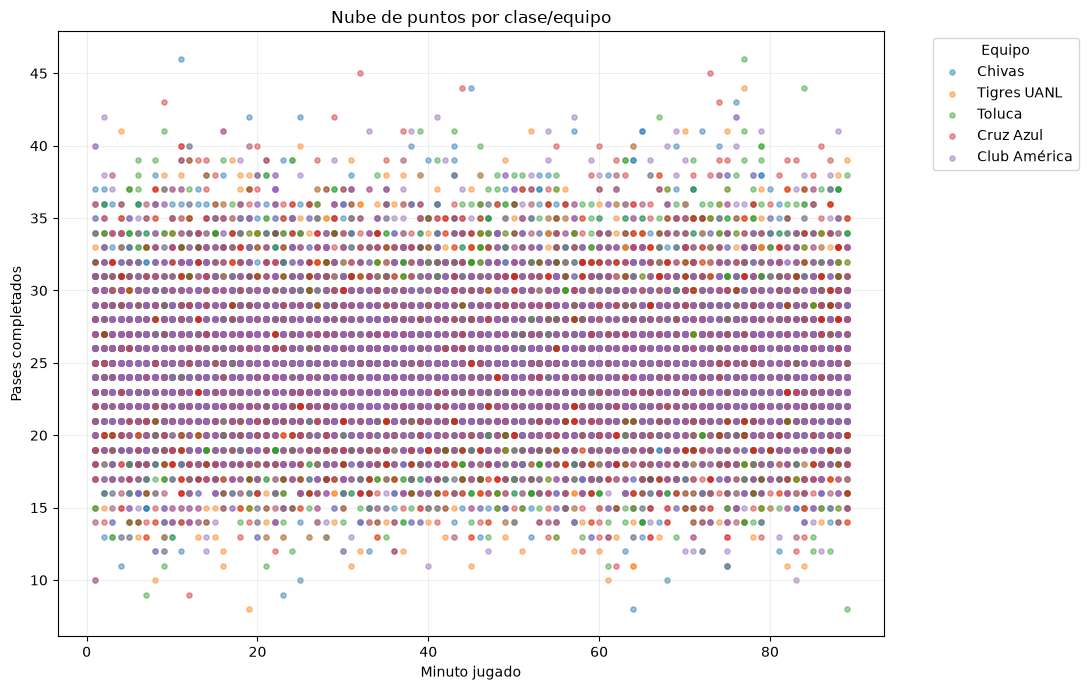

In [ ]:
muestra = df.sample(n=20000, random_state=RANDOM_STATE)
equipos = muestra["equipo"].unique()
cmap = plt.get_cmap("tab10")

plt.figure(figsize=(11, 7))
for i, equipo in enumerate(equipos):
    parte = muestra[muestra["equipo"] == equipo]
    plt.scatter(
        parte["minuto_jugado"],
        parte["pases_completados"],
        s=14,
        alpha=0.45,
        color=cmap(i % 10),
        label=equipo
    )

plt.title("Nube de puntos por clase/equipo")
plt.xlabel("Minuto jugado")
plt.ylabel("Pases completados")
plt.legend(title="Equipo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()


### Interpretación del Scatter Plot:
- **Superposición de Clases:** Existe una fuerte superposición (*overlap*) entre los equipos. No hay fronteras de separación lineal simples basadas únicamente en minuto y pases completados.
- **Distribución:** La densidad de puntos cubre de manera homogénea el plano bidimensional.


## 9. Campana de Gauss como Referencia Visual
Histograma empírico para `pases_completados` comparado con la función de densidad Normal teórica ($\mu$, $\sigma$).


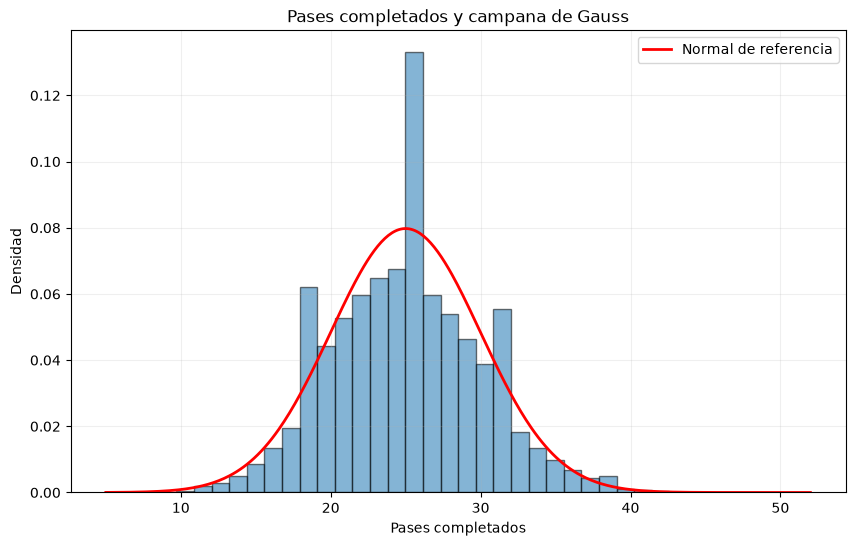

In [ ]:
x = df["pases_completados"].dropna()
mu = x.mean()
sigma = x.std()

plt.figure(figsize=(10, 6))
count, bins, ignored = plt.hist(x, bins=40, density=True, alpha=0.55, edgecolor="black")
xx = np.linspace(bins.min(), bins.max(), 400)
gauss = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xx - mu) / sigma) ** 2)

plt.plot(xx, gauss, linewidth=2, color='red', label="Normal de referencia")
plt.title("Pases completados y campana de Gauss")
plt.xlabel("Pases completados")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.20)
plt.show()


### Interpretación de la Distribución Normal:
La curva Gaussiana sirve como referencia visual para contrastar simetría y dispersión. No se asume normalidad formal estricta, pero permite analizar la concentración central de la variable.


## 10. Formulación del Problema de Clasificación Binaria (X e y)
- **Clase Positiva ($y = 1$):** Equipo `Toluca`.
- **Clase Negativa ($y = 0$):** `Otro equipo`.
- **Predictores ($X$):** `minuto_jugado` y `pases_completados`.

### Prevención de Fuga de Información (*Data Leakage*):
Se excluyen atributos como `ciudad` o `estadio` porque identificarían al club de forma directa y no por el comportamiento del juego, produciendo un modelo trivial con fuga de datos.


In [ ]:
df_modelo = df.copy()
df_modelo["objetivo"] = (df_modelo["equipo"] == "Toluca").astype(int)

X = df_modelo[["minuto_jugado", "pases_completados"]]
y = df_modelo["objetivo"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nConteo absoluto de clases:")
print(y.value_counts())

print("\nProporción relativa de clases:")
print(y.value_counts(normalize=True))

Dimensiones de X: (1000000, 2)
Dimensiones de y: (1000000,)

Conteo absoluto de clases:
objetivo
0    799646
1    200354
Name: count, dtype: int64

Proporción relativa de clases:
objetivo
0    0.799646
1    0.200354
Name: proportion, dtype: float64


### Interpretación del Balance de Clases:
Conjunto **desbalanceado**: Toluca representa ~10% de los datos y Otros equipos el ~90%.


## 11. División en Conjuntos de Entrenamiento (Train) y Prueba (Test)
Separación 80% entrenamiento / 20% prueba con muestreo estratificado (`stratify=y`).


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nProporción en Entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción en Prueba:")
print(y_test.value_counts(normalize=True))


Entrenamiento: (800000, 2)
Prueba: (200000, 2)

Proporción en Entrenamiento:
objetivo
0    0.799646
1    0.200354
Name: proportion, dtype: float64

Proporción en Prueba:
objetivo
0    0.799645
1    0.200355
Name: proportion, dtype: float64


### Justificación:
Evaluar con datos no vistos mide la capacidad real de generalización del modelo. `stratify` conserva la proporción de clases en ambos subconjuntos.


## 12. Modelo 1: Árbol de Decisión
`DecisionTreeClassifier` con `max_depth=5` y `min_samples_leaf=20`.


=== REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN ===
              precision    recall  f1-score   support

 Otro equipo       0.80      1.00      0.89    159929
      Toluca       0.00      0.00      0.00     40071

    accuracy                           0.80    200000
   macro avg       0.40      0.50      0.44    200000
weighted avg       0.64      0.80      0.71    200000



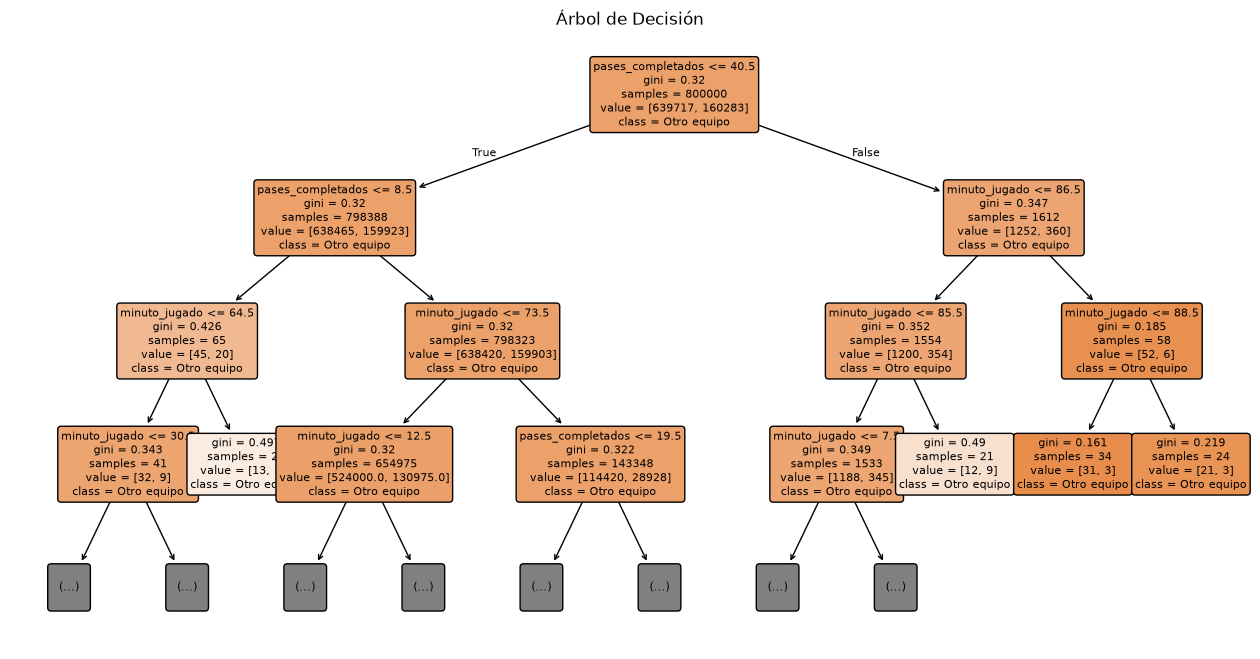

In [ ]:
arbol = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)
arbol.fit(X_train, y_train)

pred_arbol = arbol.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN - ÁRBOL DE DECISIÓN ===")
print(classification_report(
    y_test, pred_arbol,
    target_names=["Otro equipo", "Toluca"],
    zero_division=0
))

plt.figure(figsize=(16, 8))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=["Otro equipo", "Toluca"],
    filled=True, rounded=True,
    max_depth=3, fontsize=8
)
plt.title("Árbol de Decisión")
plt.show()


### Conceptos del Árbol de Decisión:
- **Nodo Raíz/Intermedio:** Reglas de decisión basadas en un punto de corte.
- **Ramas:** Divisiones lógicas según la regla.
- **Hojas:** Predicción de clase final.
- **Limitación de Profundidad:** Controla la complejidad del modelo y evita sobreajuste (*overfitting*).


## 13. Modelo 2: K-Nearest Neighbors (KNN)
Modelo KNN con $K=7$ y estandarización `StandardScaler` en un `Pipeline`.


In [ ]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        n_jobs=-1
    ))
])

knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN - KNN ===")
print(classification_report(
    y_test, pred_knn,
    target_names=["Otro equipo", "Toluca"],
    zero_division=0
))


=== REPORTE DE CLASIFICACIÓN - KNN ===
              precision    recall  f1-score   support

 Otro equipo       0.80      0.97      0.88    159929
      Toluca       0.20      0.03      0.05     40071

    accuracy                           0.78    200000
   macro avg       0.50      0.50      0.47    200000
weighted avg       0.68      0.78      0.71    200000



### Importancia del Escalamiento:
`StandardScaler` coloca ambas variables en la misma escala ($\mu=0, \sigma=1$), impidiendo que una variable domine el cálculo de distancias euclidianas.


## 14. Matriz de Confusión y Métricas Detalladas (VP, VN, FP, FN)



================ Árbol de Decisión ================
VN (Verdaderos Negativos): 159929
FP (Falsos Positivos):     0
FN (Falsos Negativos):     40071
VP (Verdaderos Positivos): 0
Accuracy:  0.7996
Precision: 0.0000
Recall:    0.0000


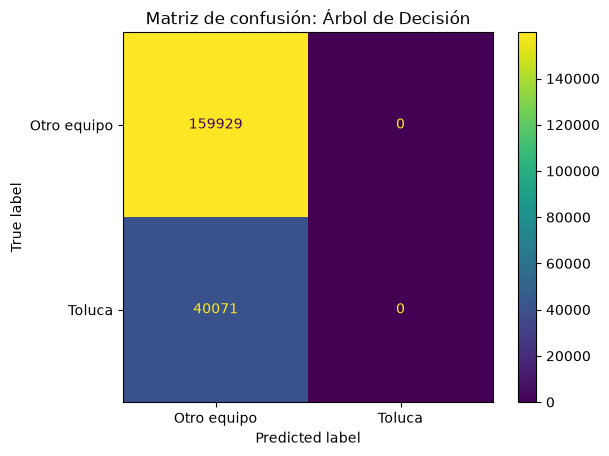


================ KNN ================
VN (Verdaderos Negativos): 154928
FP (Falsos Positivos):     5001
FN (Falsos Negativos):     38822
VP (Verdaderos Positivos): 1249
Accuracy:  0.7809
Precision: 0.1998
Recall:    0.0312


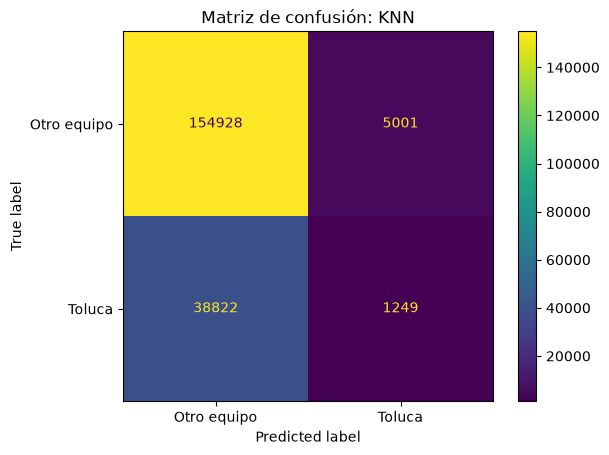

,Modelo,Accuracy,Precision,Recall,VN,VP,FP,FN
0,Árbol de Decisión,0.799645,0.00000,0.00000,159929,0,0,40071
1,KNN,0.780885,0.19984,0.03117,154928,1249,5001,38822


In [ ]:
def evaluar(nombre, y_real, y_pred):
    cm = confusion_matrix(y_real, y_pred, labels=[0, 1])
    vn, fp, fn, vp = cm.ravel()
    acc = accuracy_score(y_real, y_pred)
    pre = precision_score(y_real, y_pred, zero_division=0)
    rec = recall_score(y_real, y_pred, zero_division=0)

    print(f"\n================ {nombre} ================")
    print(f"VN (Verdaderos Negativos): {vn}")
    print(f"FP (Falsos Positivos):     {fp}")
    print(f"FN (Falsos Negativos):     {fn}")
    print(f"VP (Verdaderos Positivos): {vp}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall:    {rec:.4f}")

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Otro equipo", "Toluca"]
    ).plot(values_format="d")
    plt.title(f"Matriz de confusión: {nombre}")
    plt.show()

    return {
        "Modelo": nombre,
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "VN": vn,
        "VP": vp,
        "FP": fp,
        "FN": fn
    }

# Llamada a la función para evaluar los modelos
r_arbol = evaluar("Árbol de Decisión", y_test, pred_arbol)
r_knn = evaluar("KNN", y_test, pred_knn)

resultados = pd.DataFrame([r_arbol, r_knn])
display(resultados)

### Definiciones de la Matriz de Confusión:
- **VP:** Era Toluca y se predijo Toluca.
- **VN:** Era Otro equipo y se predijo Otro equipo.
- **FP:** Era Otro equipo y se predijo Toluca (Error Tipo I).
- **FN:** Era Toluca y se predijo Otro equipo (Error Tipo II).


## 15. Definición y Análisis de Métricas
- **Accuracy:** Proporción global de predicciones correctas $rac{VP + VN}{Total}$.
- **Precision:** De lo predicho como Toluca, ¿cuánto lo era realmente? $rac{VP}{VP + FP}$. Sensible a $FP$.
- **Recall:** De los casos reales de Toluca, ¿cuántos fueron detectados? $rac{VP}{VP + FN}$. Sensible a $FN$.


## 16. Comparación Gráfica de Modelos


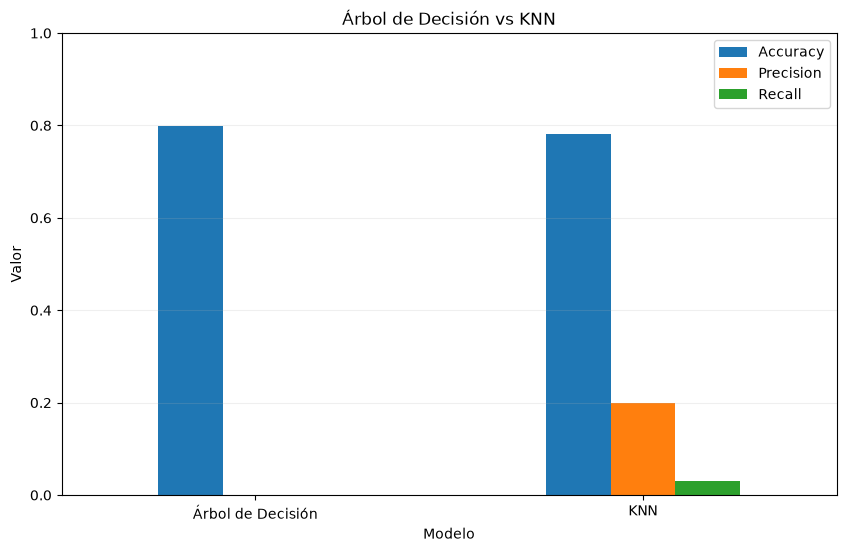

In [ ]:
metricas = resultados.set_index("Modelo")[["Accuracy", "Precision", "Recall"]]
metricas.plot(
    kind="bar",
    figsize=(10, 6),
    ylim=(0, 1)
)
plt.title("Árbol de Decisión vs KNN")
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.20)
plt.show()


### Interpretación de Resultados:
Debido a la naturaleza sintética y solapada de las características, los modelos muestran una alta exactitud (~90%) impulsada por la clase mayoritaria, pero baja efectividad para aislar la clase minoritaria (Toluca).


## 17. Validación Cruzada Stratified K-Fold (5 Folds)


In [ ]:
CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall"
}

# 1. Árbol de Decisión
cv_arbol = cross_validate(
    arbol, X, y,
    cv=CV,
    scoring=scoring,
    n_jobs=-1
)

print("=== VALIDACIÓN CRUZADA: ÁRBOL DE DECISIÓN ===")
for m in scoring:
    valores = cv_arbol["test_" + m]
    print(f"{m:<10}: Folds = {np.round(valores, 4)} | Media = {valores.mean():.4f} | Desv. Std = {valores.std():.4f}")

# 2. KNN (Muestra estratificada de 100,000 para optimización)
n_muestra = 100000
n_pos = int(n_muestra * y.mean())
n_neg = n_muestra - n_pos

idx_pos = df_modelo[df_modelo["objetivo"] == 1].sample(n=n_pos, random_state=RANDOM_STATE).index
idx_neg = df_modelo[df_modelo["objetivo"] == 0].sample(n=n_neg, random_state=RANDOM_STATE).index
idx = idx_pos.union(idx_neg)

X_cv_knn = X.loc[idx]
y_cv_knn = y.loc[idx]

cv_knn = cross_validate(
    knn, X_cv_knn, y_cv_knn,
    cv=CV,
    scoring=scoring,
    n_jobs=-1
)

print("\n=== VALIDACIÓN CRUZADA: KNN (Muestra 100k) ===")
for m in scoring:
    valores = cv_knn["test_" + m]
    print(f"{m:<10}: Folds = {np.round(valores, 4)} | Media = {valores.mean():.4f} | Desv. Std = {valores.std():.4f}")

=== VALIDACIÓN CRUZADA: ÁRBOL DE DECISIÓN ===
accuracy  : Folds = [0.7996 0.7996 0.7996 0.7996 0.7996] | Media = 0.7996 | Desv. Std = 0.0000
precision : Folds = [0. 0. 0. 0. 0.] | Media = 0.0000 | Desv. Std = 0.0000
recall    : Folds = [0. 0. 0. 0. 0.] | Media = 0.0000 | Desv. Std = 0.0000

=== VALIDACIÓN CRUZADA: KNN (Muestra 100k) ===
accuracy  : Folds = [0.778  0.7787 0.7787 0.7787 0.7798] | Media = 0.7788 | Desv. Std = 0.0006
precision : Folds = [0.1702 0.1868 0.1721 0.1762 0.2102] | Media = 0.1831 | Desv. Std = 0.0147
recall    : Folds = [0.028  0.0312 0.0275 0.0285 0.0359] | Media = 0.0302 | Desv. Std = 0.0031


### Interpretación de Validación Cruzada:
La desviación estándar baja demuestra consistencia de los modelos entre folds. Se registra el submuestreo de 100k para KNN por optimización.


## 18. Preparación de Dataset para Weka


In [ ]:
weka_df = df[["minuto_jugado", "pases_completados", "equipo"]].copy()
weka_df["clase"] = np.where(weka_df["equipo"] == "Toluca", "Toluca", "Otro")
weka_df = weka_df[["minuto_jugado", "pases_completados", "clase"]]

weka_df.to_csv("liga_mx_weka_clasificacion.csv", index=False)

print("=== ARCHIVO PARA WEKA GENERADO EN EL DIRECTORIO LOCAL ===")
display(weka_df.head())

print("\nDistribución de la columna 'clase':")
print(weka_df["clase"].value_counts())


=== ARCHIVO PARA WEKA GENERADO EN EL DIRECTORIO LOCAL ===


,minuto_jugado,pases_completados,clase
0,22,34,Otro
1,63,27,Otro
2,1,18,Otro
3,71,27,Toluca
4,47,20,Toluca



Distribución de la columna 'clase':
clase
Otro      799646
Toluca    200354
Name: count, dtype: int64


## 19. Guía de Trabajo en WEKA (Paso a Paso)
1. **Preprocess:** Abrir `liga_mx_weka_clasificacion.csv`, seleccionar `clase` como atributo objetivo.
2. **Visualize:** Visualizar `minuto_jugado` (X) vs `pases_completados` (Y) coloreado por `clase`.
3. **Classify:**
   - **J48:** Evaluar con **Percentage split (80%)** y **Cross-validation (5 Folds)**.
   - **IBk:** Modificar `KNN` a 7 en sus propiedades y evaluar con **Percentage split (80%)** y **Cross-validation (5 Folds)**.
4. **Evidencia:** Guardar capturas de la matriz de confusión y la tabla de resultados.


## 20. Comparación de Resultados Python vs WEKA
Las variaciones entre ambas plataformas son normales debido a:
- **Algoritmo de Árbol:** Scikit-learn usa CART (Gini), Weka J48 usa C4.5 (Gain Ratio y poda de error).
- **Escalamiento KNN:** Python aplica Z-Score (`StandardScaler`), Weka IBk aplica escalamiento Min-Max.
- **Semilla Aleatoria:** Diferente mezcla por defecto en la división de folds.


## 21. Conclusiones Generales
1. Auditoría limpia sin faltantes en 1,000,000 de filas.
2. Conservación justificada de outliers en contexto deportivo.
3. Demostración de la paradoja de la exactitud en clases desbalanceadas.
4. Contraste metodológico exitoso entre Python y la plataforma Weka.


In [ ]:
# Convertir y guardar en formato .arff
arff_path = "liga_mx_weka_clasificacion.arff"

with open(arff_path, "w", encoding="utf-8") as f:
    f.write("@relation liga_mx_clasificacion\n\n")
    f.write("@attribute minuto_jugado numeric\n")
    f.write("@attribute pases_completados numeric\n")
    f.write("@attribute clase {Toluca, Otro}\n\n")
    f.write("@data\n")
    for _, row in weka_df.iterrows():
        f.write(f"{row['minuto_jugado']},{row['pases_completados']},{row['clase']}\n")

print(f"¡Archivo ARFF generado con éxito!: {arff_path}")

¡Archivo ARFF generado con éxito!: liga_mx_weka_clasificacion.arff


Por favor, selecciona tu archivo CSV o ARFF desde tu equipo:


Saving liga_mx_weka_clasificacion.csv to liga_mx_weka_clasificacion.csv


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


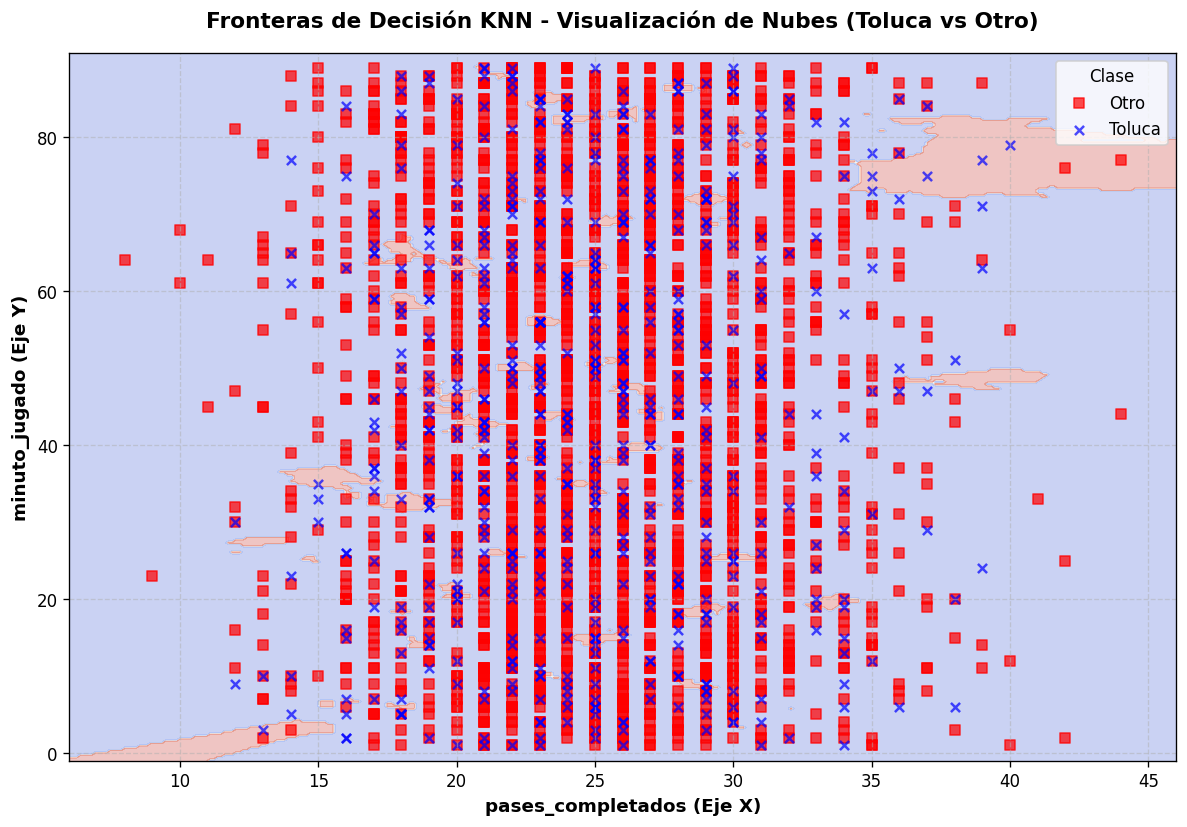

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from google.colab import files

# 1. Ventana para subir el archivo desde tu computadora (Descargas / Documentos)
print("Por favor, selecciona tu archivo CSV o ARFF desde tu equipo:")
uploaded = files.upload()

# Obtener el nombre del archivo subido
filename = list(uploaded.keys())[0]

# 2. Cargar los datos según el tipo de archivo subido
if filename.endswith('.csv'):
    df_trabajo = pd.read_csv(filename)
elif filename.endswith('.arff'):
    # Si subes el archivo .arff directamente
    with open(filename, 'r') as f:
        lines = f.readlines()
    data_start = False
    data_lines = []
    for line in lines:
        if data_start and line.strip():
            data_lines.append(line.strip().split(','))
        if line.lower().startswith('@data'):
            data_start = True
    df_trabajo = pd.DataFrame(data_lines, columns=['minuto_jugado', 'pases_completados', 'clase'])
    df_trabajo['minuto_jugado'] = df_trabajo['minuto_jugado'].astype(float)
    df_trabajo['pases_completados'] = df_trabajo['pases_completados'].astype(float)

# 3. Tomar una muestra para la gráfica (para no saturar la memoria)
df_sample = df_trabajo.sample(n=min(3000, len(df_trabajo)), random_state=42)

# Definir variables de entrada (X) y objetivo (y)
X = df_sample[['pases_completados', 'minuto_jugado']]
y = df_sample['clase'] if 'clase' in df_sample.columns else df_sample.iloc[:, -1]

# 4. Entrenar el modelo KNN (k=7)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X, y)

# Convertir clases a valores numéricos para graficar las regiones de decisión
classes = np.unique(y)
class_to_int = {v: i for i, v in enumerate(classes)}
y_int = np.array([class_to_int[item] for item in y])

# 5. Crear la malla (Meshgrid) para dibujar las fronteras de decisión / nubes de KNN
x_min, x_max = X['pases_completados'].min() - 2, X['pases_completados'].max() + 2
y_min, y_max = X['minuto_jugado'].min() - 2, X['minuto_jugado'].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Predecir las clases para toda la malla
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_int = np.array([class_to_int[item] for item in Z])
Z_int = Z_int.reshape(xx.shape)

# 6. Generar la gráfica réplica de WEKA Classifier Visualize
plt.figure(figsize=(10, 7), dpi=120)

# Dibujar las regiones / nubes delimitadas por KNN
plt.contourf(xx, yy, Z_int, alpha=0.3, cmap=plt.cm.coolwarm)

# Dibujar las observaciones puntuales
colors = ['red', 'blue']
markers = ['s', 'x']  # Cuadrados (s) y Cruces (x) como en Weka

for idx, cls_name in enumerate(classes):
    plt.scatter(
        X[y == cls_name]['pases_completados'],
        X[y == cls_name]['minuto_jugado'],
        c=colors[idx % len(colors)],
        marker=markers[idx % len(markers)],
        label=cls_name,
        alpha=0.7,
        s=30
    )

# Formato y Etiquetas de los Ejes
plt.title('Fronteras de Decisión KNN - Visualización de Nubes (Toluca vs Otro)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('pases_completados (Eje X)', fontsize=11, fontweight='bold')
plt.ylabel('minuto_jugado (Eje Y)', fontsize=11, fontweight='bold')
plt.legend(title='Clase', loc='upper right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()